In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'/content/Olimpic Data.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
data = df.copy()

In [4]:
data.size

4066740

In [5]:
data.shape

(271116, 15)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [7]:
data.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [8]:
#lower case the columns name
data.columns = data.columns.str.lower()

In [9]:
data[['age','height','weight']].isnull().sum()

,0
age,9474
height,60171
weight,62875


In [10]:
data.groupby('sport')[['age','height','weight']].apply(lambda x: x.isnull().sum())

,age,height,weight
sport,,,
Aeronautics,0,1,1
Alpine Skiing,78,2435,2479
Alpinism,9,25,25
Archery,80,389,448
Art Competitions,507,3519,3523
...,...,...,...
Tug-Of-War,44,145,118
Volleyball,9,121,127
Water Polo,200,1058,1122


In [11]:
data['age'] = data['age'].fillna(data['age'].median())

In [12]:
data['height'] = data['height'].fillna(data['height'].median())

In [28]:
data['weight'] = data['weight'].fillna(data['weight'].median())

In [33]:
data[['age','height','weight']].isnull().sum()

,0
age,0
height,0
weight,0


In [34]:
label = LabelEncoder()

data['sex_encoded'] = label.fit_transform(data['sex'])
data['sport_encoded'] = label.fit_transform(data['sport'])
data['has_medal'] = (data['medal'].notna()).astype(int)

X = data[['sex_encoded', 'age', 'height', 'sport_encoded', 'has_medal', 'year']]
y = data['weight']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Scaling Data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
def knn_func(train_x, train_label, test_x, k):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(train_x, train_label)
    y_pred = knn.predict(test_x)
    return y_pred

In [38]:
# Create list to store results
results = []

# Test different K values (odd numbers, standard practice)
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

print("Testing different K values...")
print("="*50)

# For EACH K value:
for k in k_values:
    # 1. Make predictions
    y_pred = knn_func(X_train, y_train, X_test, k)

    # 2. Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # 3. Print for this K
    print(f"K={k:2d} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

    # 4. Store results
    results.append({
        'k': k,
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })
print("="*50)

# Find best K (highest R²)
best = max(results, key=lambda x: x['r2'])
print(f"\nBEST K: {best['k']}")
print(f"Best MAE: {best['mae']:.4f}")
print(f"Best RMSE: {best['rmse']:.4f}")
print(f"Best R²: {best['r2']:.4f}")


Testing different K values...
K= 1 | MAE: 4.3676 | RMSE: 8.4917 | R²: 0.5450
K= 3 | MAE: 4.2467 | RMSE: 7.3570 | R²: 0.6585
K= 5 | MAE: 4.2230 | RMSE: 7.0968 | R²: 0.6822
K= 7 | MAE: 4.2120 | RMSE: 6.9935 | R²: 0.6914
K= 9 | MAE: 4.2201 | RMSE: 6.9593 | R²: 0.6944
K=11 | MAE: 4.2222 | RMSE: 6.9287 | R²: 0.6971
K=13 | MAE: 4.2228 | RMSE: 6.9090 | R²: 0.6988
K=15 | MAE: 4.2246 | RMSE: 6.9044 | R²: 0.6992
K=17 | MAE: 4.2295 | RMSE: 6.8980 | R²: 0.6998
K=19 | MAE: 4.2296 | RMSE: 6.8934 | R²: 0.7002
K=21 | MAE: 4.2295 | RMSE: 6.8917 | R²: 0.7003

BEST K: 21
Best MAE: 4.2295
Best RMSE: 6.8917
Best R²: 0.7003


In [39]:
# Use best K from testing above
best_k = best['k']

final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Show final metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Using BEST K = {best_k}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Using BEST K = 21
MAE: 4.2295
RMSE: 6.8917
R²: 0.7003


In [42]:
new_athlete_data = {
    'sex_encoded': [0],
    'age': [28],
    'height': [185],
    'sport_encoded': [8],
    'has_medal': [0],
    'year': [2020]
}
new_athlete_df = pd.DataFrame(new_athlete_data)
new_athlete_scaled = scaler.transform(new_athlete_df)
# Make prediction using the final_model (best K=21) from cell XVYF42urd0W2
prediction = final_model.predict(new_athlete_scaled)
print(f"Predicted weight for new athlete: {prediction[0]:.1f} kg")

Predicted weight for new athlete: 78.4 kg


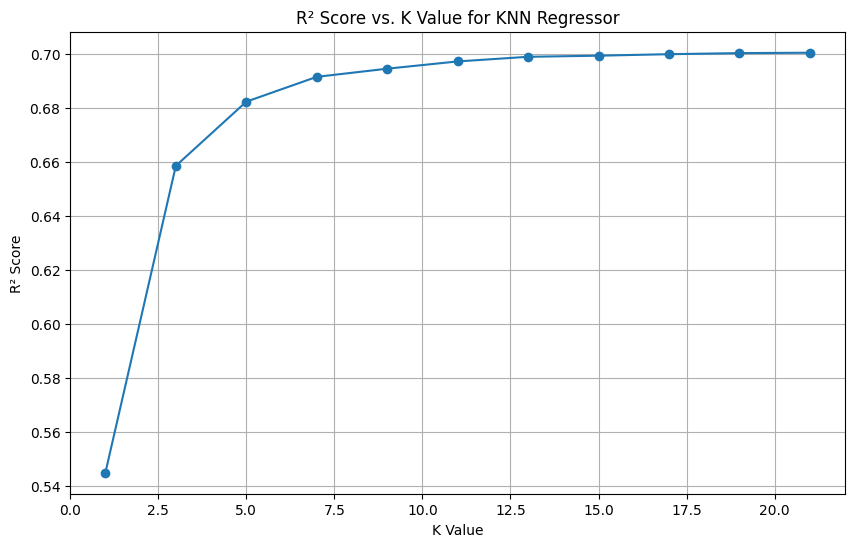

In [41]:
k_vals = [res['k'] for res in results]
r2_vals = [res['r2'] for res in results]

plt.figure(figsize=(10, 6))
plt.plot(k_vals, r2_vals, marker='o')
plt.xlabel('K Value')
plt.ylabel('R² Score')
plt.title('R² Score vs. K Value for KNN Regressor')
plt.grid(True)
plt.show()